## Customer Churn Prediction using ANN

### Problem Statement

Customer churn is one of the major challenges faced by banks and financial institutions. The objective of this project is to predict whether a customer will leave the bank or continue using its services based on customer-related features such as credit score, geography, gender, age, balance, salary, and account activity.

In this project, an Artificial Neural Network (ANN) classification model is developed using Deep Learning techniques to analyze customer behavior and predict churn accurately. The model helps businesses identify customers who are likely to leave so that retention strategies can be applied effectively.

### Importing Libraries

In [2]:
# Import important libraries
import numpy as np
import pandas as pd
import seaborn as sns

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import callbacks
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error as mae
import seaborn as sns
%matplotlib inline

# for Interactive shells
from IPython.display import display

#removing warnings
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter('ignore')

C:\Users\ariya\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Importing Dataset

In [3]:
df = pd.read_csv(r"C:\Users\ariya\Downloads\Churn_Modelling.csv",index_col='RowNumber')
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1.2 MB


In [5]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
# Some columns are totally unproductive so lets remove them
df.drop(['CustomerId','Surname'],axis=1,inplace=True)

In [7]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,
1,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,699,France,Female,39,1,0.00,2,0,0,93826.63,0
5,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.Geography.value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
# Some columns have twxt data sonlets one hot encode them
df = pd.get_dummies(prefix='Geo', data=df, columns=['Geography'])
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geo_France,Geo_Germany,Geo_Spain
RowNumber,,,,,,,,,,,,,
1,619,Female,42,2,0.00,1,1,1,101348.88,1,True,False,False
2,608,Female,41,1,83807.86,1,0,1,112542.58,0,False,False,True
3,502,Female,42,8,159660.80,3,1,0,113931.57,1,True,False,False
4,699,Female,39,1,0.00,2,0,0,93826.63,0,True,False,False
5,850,Female,43,2,125510.82,1,1,1,79084.10,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,771,Male,39,5,0.00,2,1,0,96270.64,0,True,False,False
9997,516,Male,35,10,57369.61,1,1,1,101699.77,0,True,False,False
9998,709,Female,36,7,0.00,1,0,1,42085.58,1,True,False,False


In [10]:
df = df.replace(to_replace={'Gender': {'Female': 1, 'Male':0}})

In [11]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geo_France,Geo_Germany,Geo_Spain
RowNumber,,,,,,,,,,,,,
1,619,1,42,2,0.00,1,1,1,101348.88,1,True,False,False
2,608,1,41,1,83807.86,1,0,1,112542.58,0,False,False,True
3,502,1,42,8,159660.80,3,1,0,113931.57,1,True,False,False
4,699,1,39,1,0.00,2,0,0,93826.63,0,True,False,False
5,850,1,43,2,125510.82,1,1,1,79084.10,0,False,False,True


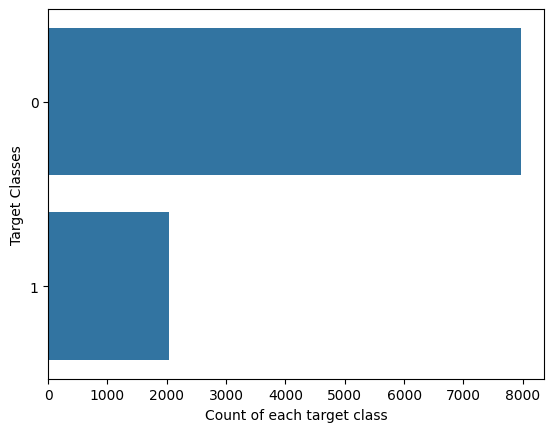

In [12]:
sns.countplot(y=df.Exited, data=df)
plt.xlabel('Count of each target class')
plt.ylabel('Target Classes')
plt.show()

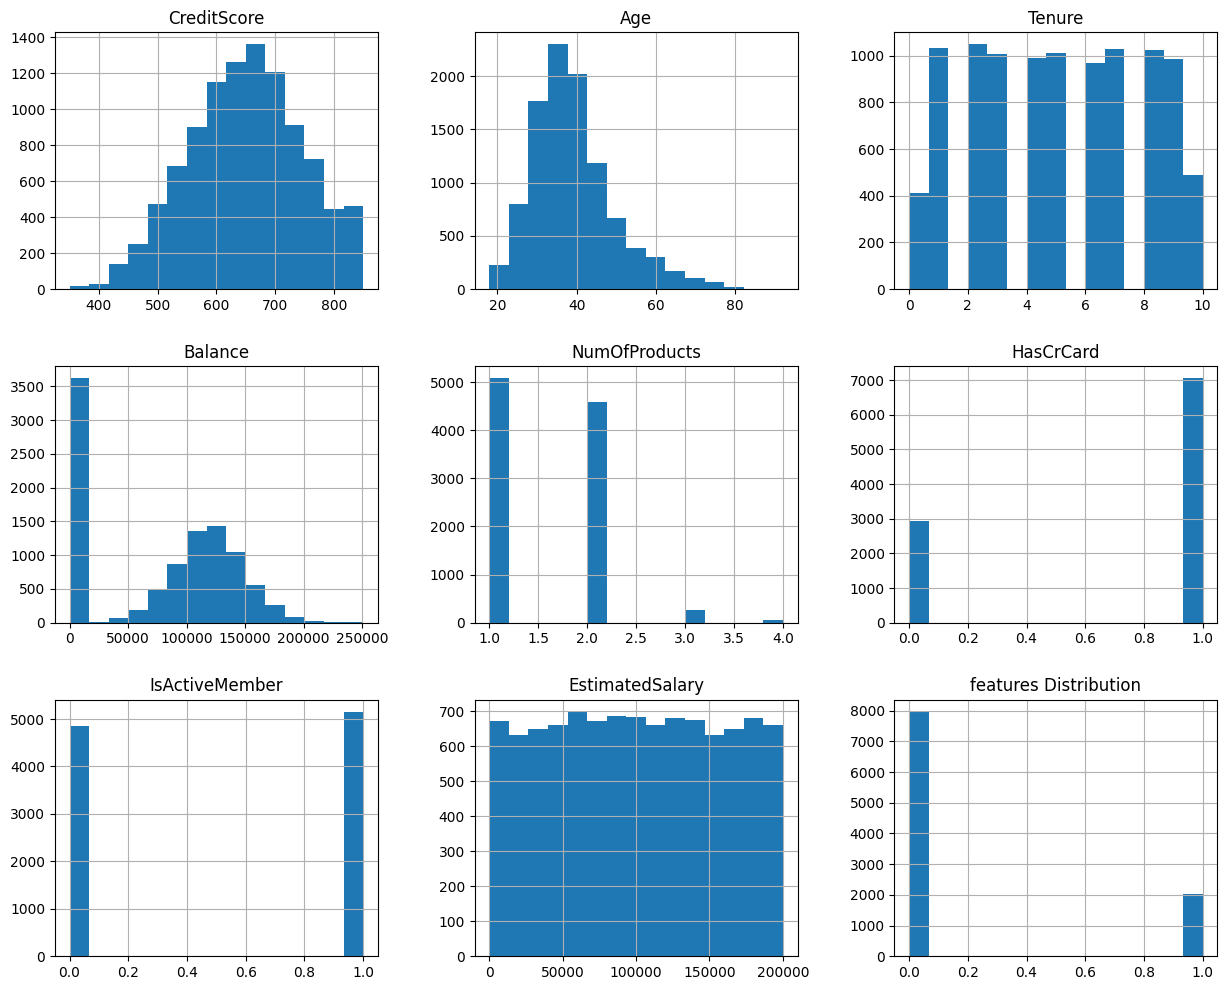

In [13]:
df.hist(figsize=(15,12), bins=15)
plt.title('features Distribution')
plt.show()

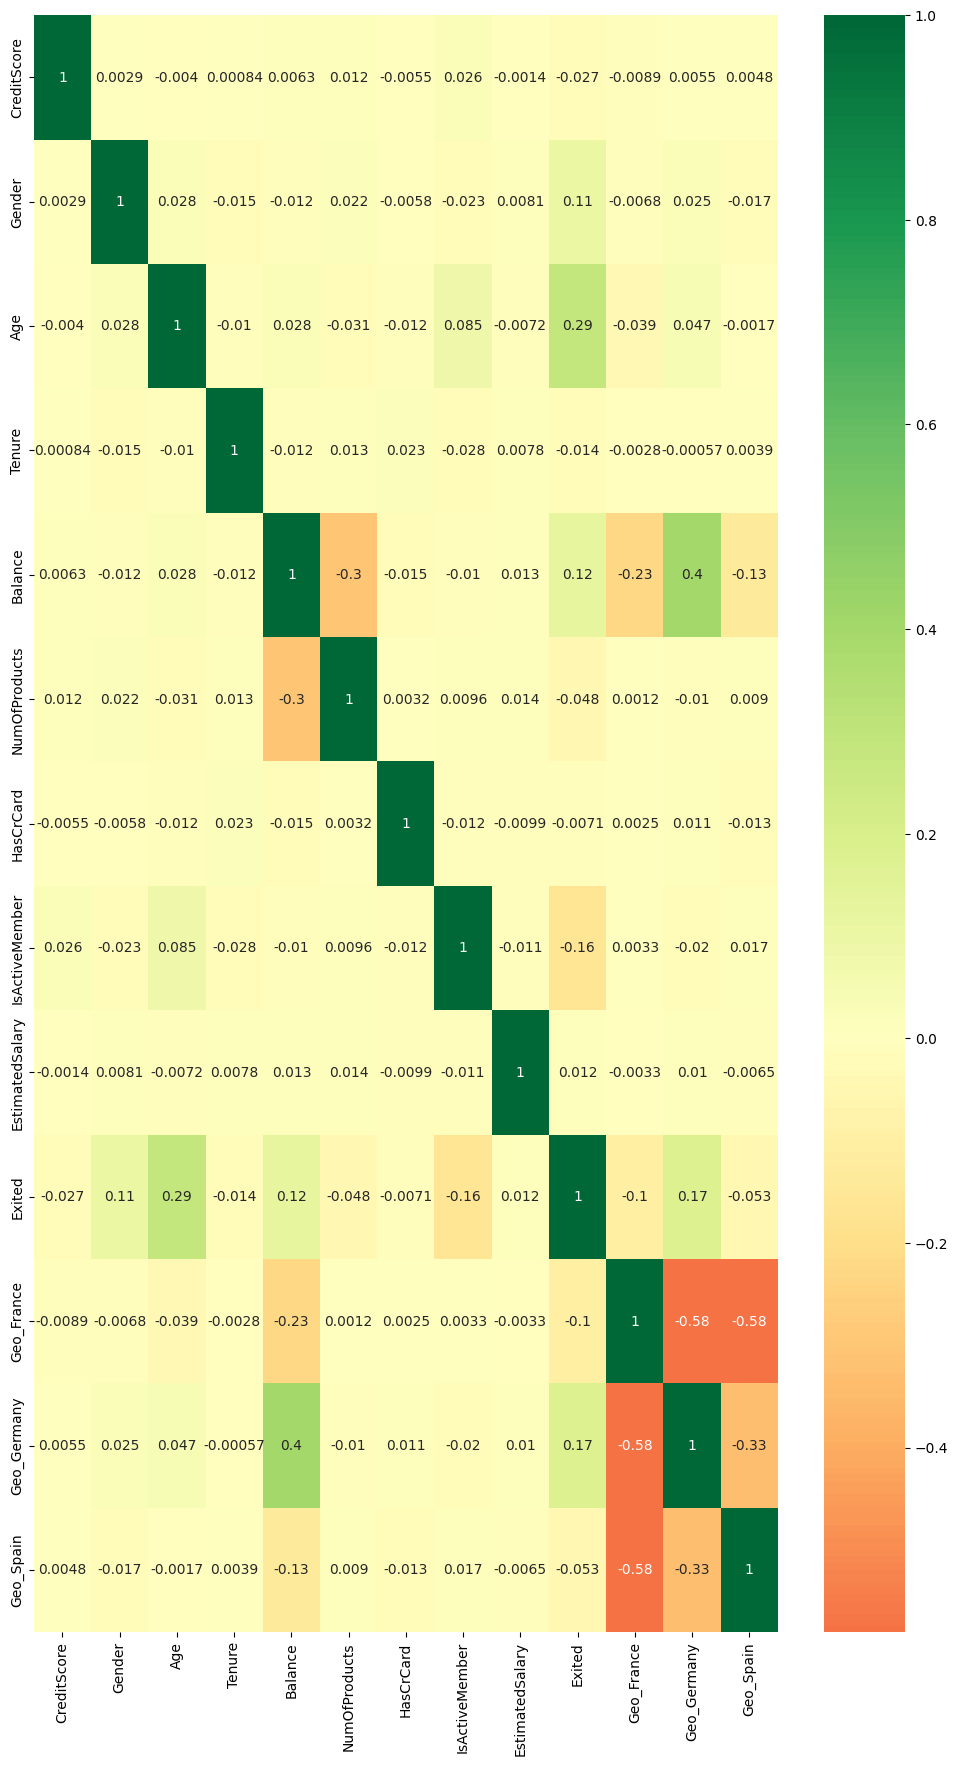

In [14]:
plt.figure(figsize=(12,21))
p=sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.show()

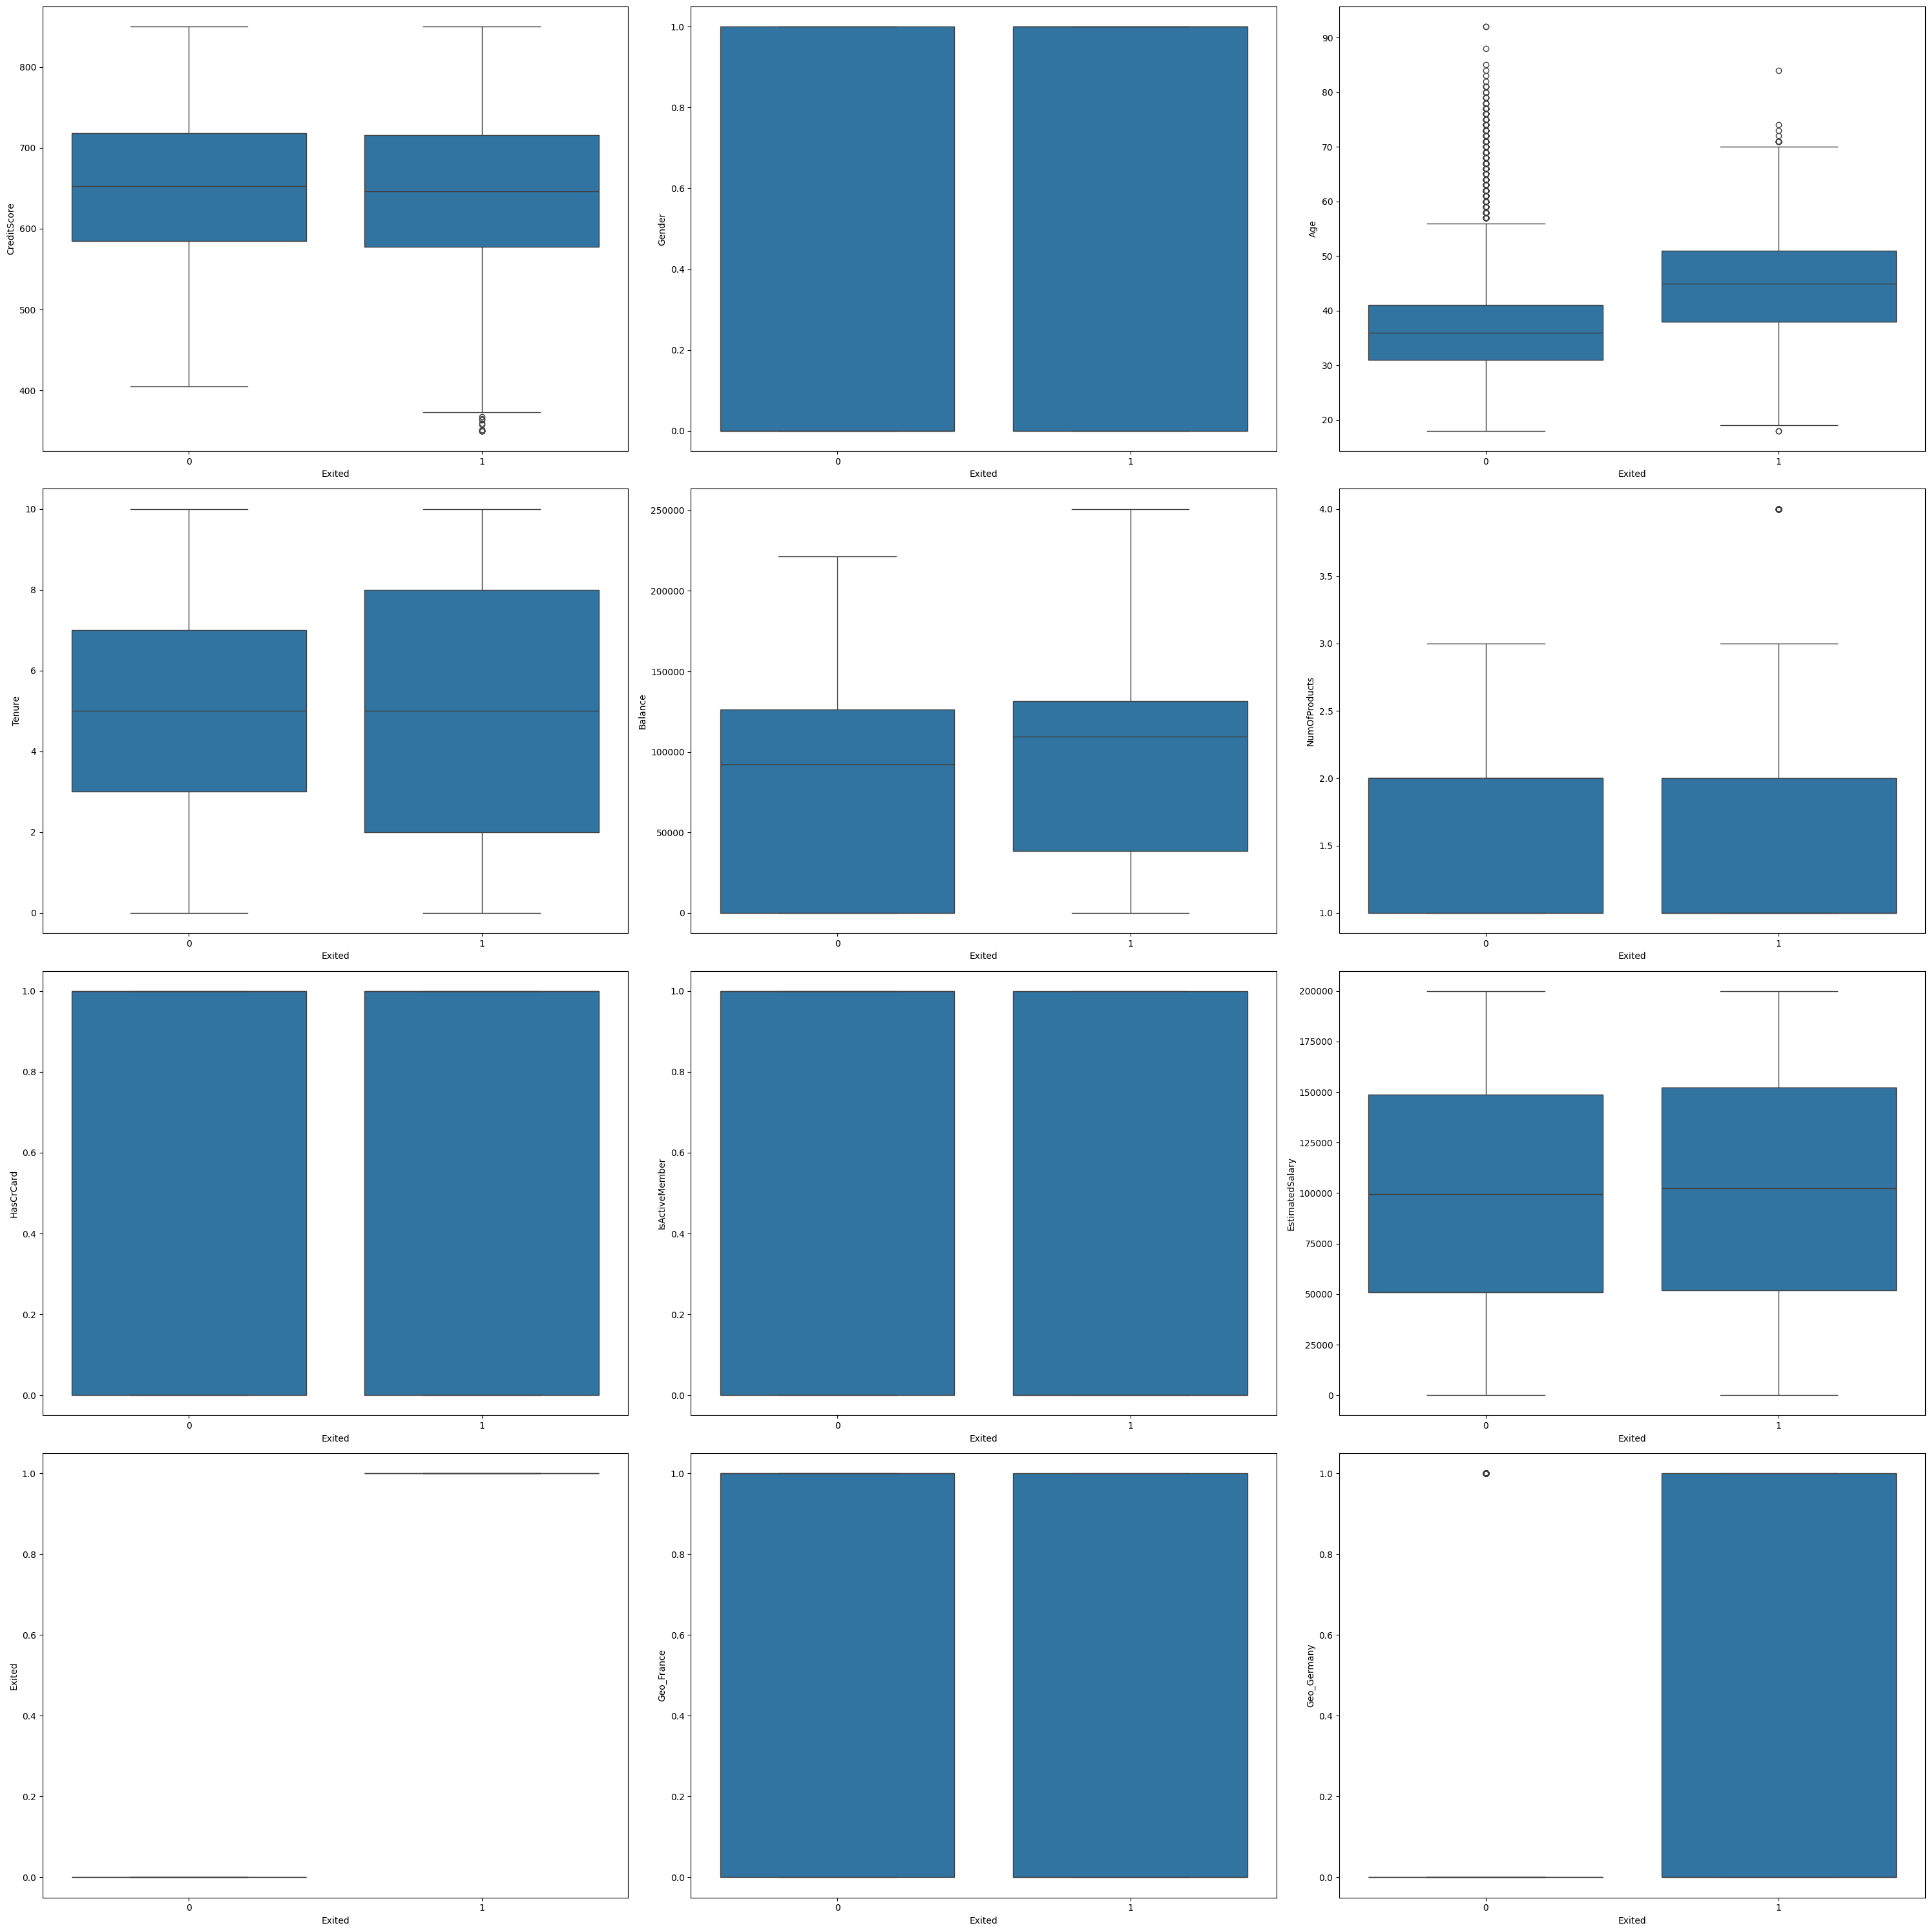

In [15]:
fig,ax = plt.subplots(nrows = 4, ncols=3, figsize=(30,30))
row = 0
col = 0
for i in range(len(df.columns) -1):
    if col > 2:
        row += 1
        col = 0
    axes = ax[row,col]
    sns.boxplot(x = df['Exited'], y = df[df.columns[i]],ax = axes)
    col += 1
plt.tight_layout()
# plt.title("Individual Features by Class")
plt.show()

### Splitting the data

In [16]:
X = df.drop(['Exited'],axis=1)
y = df.Exited

In [17]:
X.shape

(10000, 12)

In [18]:
# Split the dataset into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 0)

In [19]:
# Feature Scaling because yeswe don't wnat one independent variable dominating the other ant it makes computattoions easy.
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Building an ANN Model

In [20]:
# Building the ANN
model = Sequential()
 
# Adding the input layer and the first hidden layer
model.add(Dense(units = 100, activation = 'relu', input_dim = 12))
 
# Adding the second hidden layer
model.add(Dense(units = 150, activation = 'relu'))
 
# Adding the Third hidden layer
model.add(Dense(units = 200, activation = 'relu'))
 
# Adding the output layer
model.add(Dense(units = 1, activation = 'sigmoid')) # For output we use sigmoid.

In [21]:
model.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 100)                 │           1,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 150)                 │          15,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 200)                 │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,851 (183.01 KB)

 Trainable params: 46,851 (183.01 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Fitting the ANN to the Training set.
EPOCHS = 100 # An epoch is one complete pass through the entire training dataset.
BATCH_SIZE = 64 # Batch size is the number of training samples that pass forward and backward through a neural network.

# TRAIN MODEL
H = model.fit(X_train,
              y_train,
              batch_size = BATCH_SIZE,
              epochs = EPOCHS,
              verbose =1)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8173 - loss: 0.4268 
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8511 - loss: 0.3607 
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8583 - loss: 0.3458   
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8624 - loss: 0.3391   
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8647 - loss: 0.3337    
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8624 - loss: 0.3289 
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8671 - loss: 0.3234    
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8666 - loss: 0.3199 
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8709 - loss: 0.3164 
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8723 - loss: 0.3110 
Epoch 11/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8679 - loss: 0.3065 
Epoch 12/100
110/110

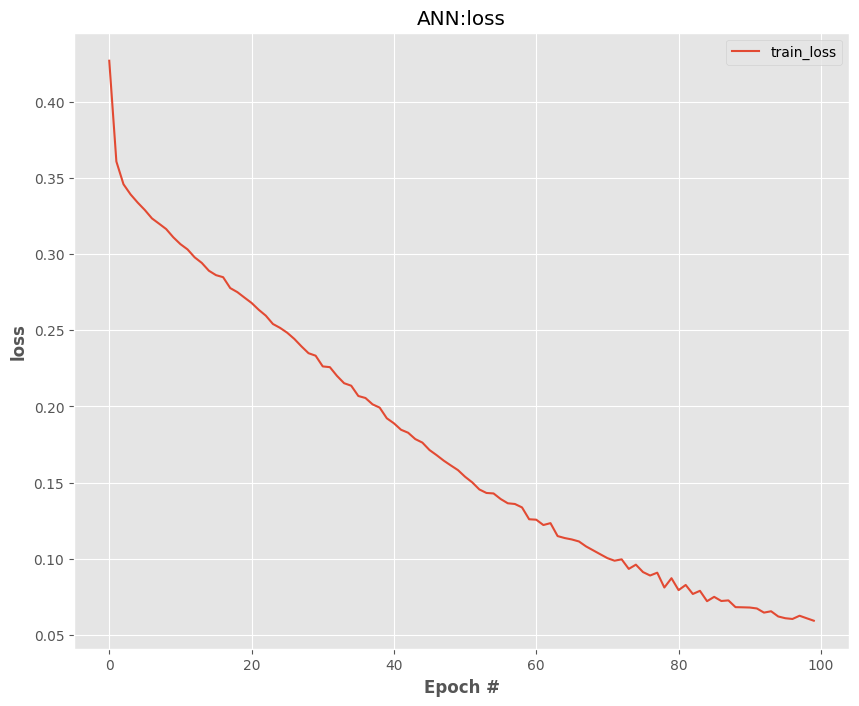

In [24]:
# plot the training and validation loss
N = np.arange(0, EPOCHS)
plt.style.use('ggplot')
plt.figure(figsize=[10,8])
plt.plot(N, H.history['loss'], label='train_loss')
plt.title('ANN:loss')
plt.xlabel('Epoch #', weight='bold')
plt.ylabel('loss', weight='bold')
plt.legend()
plt.show()

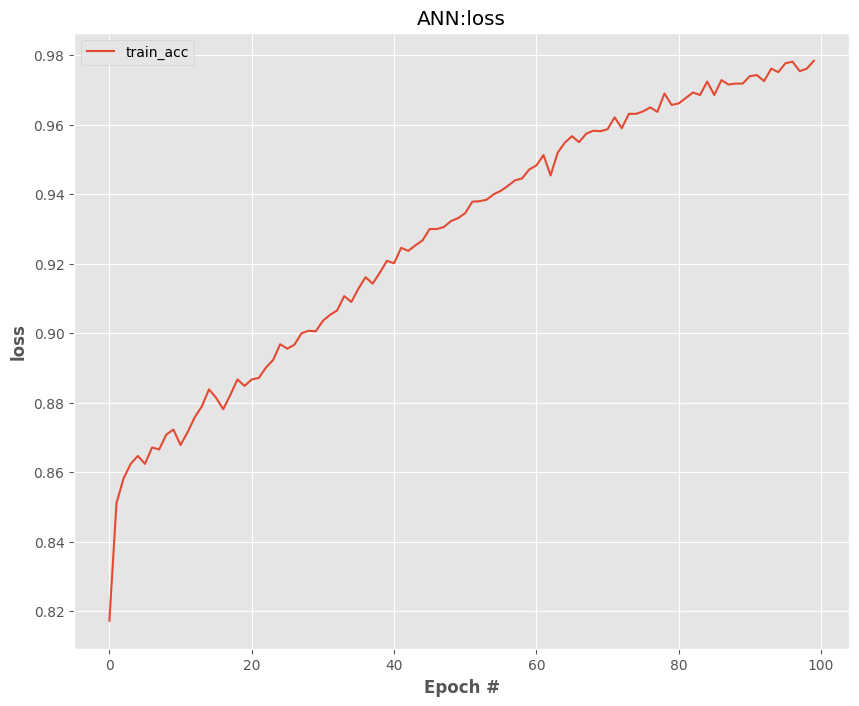

In [25]:
# plot the training and validation loss
N = np.arange(0, EPOCHS)
plt.style.use('ggplot')
plt.figure(figsize=[10,8])
plt.plot(N, H.history['accuracy'], label='train_acc')
plt.title('ANN:loss')
plt.xlabel('Epoch #', weight='bold')
plt.ylabel('loss', weight='bold')
plt.legend()
plt.show()

In [26]:
score, acc = model.evaluate(X_train, y_train,
                            batch_size=10)
print('Train score:', score)
print('Train accuracy:', acc)

700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9824 - loss: 0.0497
Train score: 0.04970618709921837
Train accuracy: 0.9824285507202148


In [27]:
# Part 3 Making predictions and evaluating the model

# predicting the test set results 
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

print('*'*20)
score, acc = model.evaluate(X_test, y_test,
                            batch_size=10)

print('Test score:', score)
print('Test accuracy:', acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   
********************
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8140 - loss: 1.1783  
Test score: 1.1782907247543335
Test accuracy: 0.8140000104904175


In [28]:
# Making the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

### 11.Evaluation Metrics

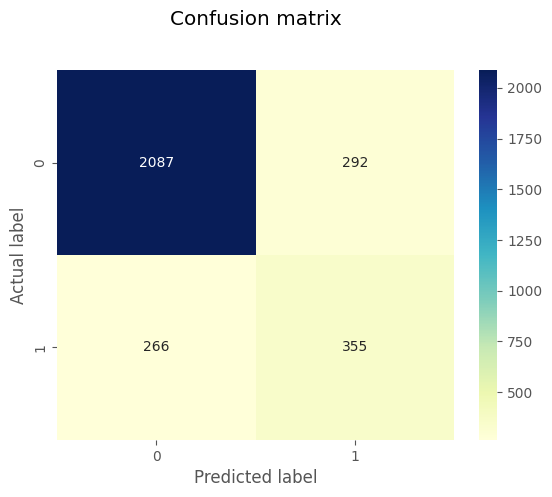

In [29]:
p = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='YlGnBu', fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show();

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      2379
           1       0.55      0.57      0.56       621

    accuracy                           0.81      3000
   macro avg       0.72      0.72      0.72      3000
weighted avg       0.82      0.81      0.82      3000



94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


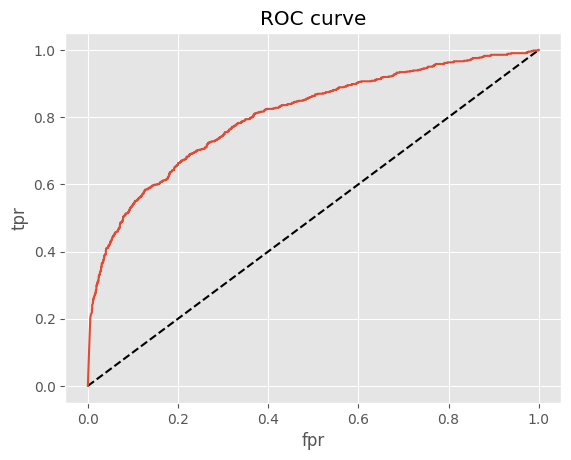

In [31]:
from sklearn.metrics import roc_curve
y_pred_proba = model.predict(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
plt.plot([0,1],[0,1], 'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curve')
plt.show()

In [32]:
#Area under ROC curve 
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred_proba)

0.8041220854240575

In [34]:
!pip install scikeras

In [35]:
# Part 4 - Evaluating, Improving and Tuning the ANN
 
# Evaluating the ANN
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score
from keras.models import Sequential
from keras.layers import Dense
def build_classifier():
    classifier = Sequential()
    classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu', input_dim = 12))
    classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
    classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    return classifier
classifier = KerasClassifier(build_fn = build_classifier, batch_size = 64, epochs = 50,verbose=1)
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
mean = accuracies.mean()
variance = accuracies.std()

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7984 - loss: 0.6663 
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.5314 
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.4492 
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.4374 
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.4333 
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7983 - loss: 0.4306   
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.4286   
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.4271 
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.4256 
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.4242 
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - loss: 0.4227 
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accura

In [37]:
print('Mean accuracy score of 10 different models using kfold cross validation : {}'.format(mean))
print('standard deviation of accuracy score of 10 different models using kfold cross validation : {}'.format(variance)) 

Mean accuracy score of 10 different models using kfold cross validation : 0.8355714285714286
standard deviation of accuracy score of 10 different models using kfold cross validation : 0.011874342087037918


### 13 Improving ANN with Dropout layer

In [38]:
# Improving the ANN
from tensorflow.keras.layers import Dropout
classifier = Sequential()
# Adding the input layer and the first hidden layer
classifier.add(Dense(units = 10, activation = 'relu', input_dim = 12))
classifier.add(Dropout(rate = 0.1))
 
# Adding the second hidden layer
classifier.add(Dense(units = 6, activation = 'relu'))
classifier.add(Dropout(rate = 0.1))
 
# Adding the output layer
classifier.add(Dense(units = 1, activation = 'sigmoid'))
 
# Compiling the ANN
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
 
# Fitting the ANN to the Training set
classifier.fit(X_train, y_train, batch_size = 64, epochs = 50,verbose = 1)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7563 - loss: 0.5937 
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7949 - loss: 0.5298   
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7964 - loss: 0.5000   
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7973 - loss: 0.4781 
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7973 - loss: 0.4650  
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7971 - loss: 0.4557 
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7976 - loss: 0.4547 
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7973 - loss: 0.4500   
Epoch 9/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7977 - loss: 0.4445   
Epoch 10/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7976 - loss: 0.4464   
Epoch 11/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7977 - loss: 0.4401   
Epoch 12/50
110/110 ━━━━━━━━

In [39]:
 

# Part 3 - Making predictions and evaluating the model
 
score, acc = classifier.evaluate(X_train, y_train,
                            batch_size=10)
print('Train score:', score)
print('Train accuracy:', acc)
# Part 3 - Making predictions and evaluating the model
 
# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)
 
print('*'*20)
score, acc = classifier.evaluate(X_test, y_test,
                            batch_size=10)
print('Test score:', score)
print('Test accuracy:', acc)
 
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8561 - loss: 0.3577
Train score: 0.3577478229999542
Train accuracy: 0.8561428785324097
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   
********************
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8527 - loss: 0.3624  
Test score: 0.3623744249343872
Test accuracy: 0.8526666760444641


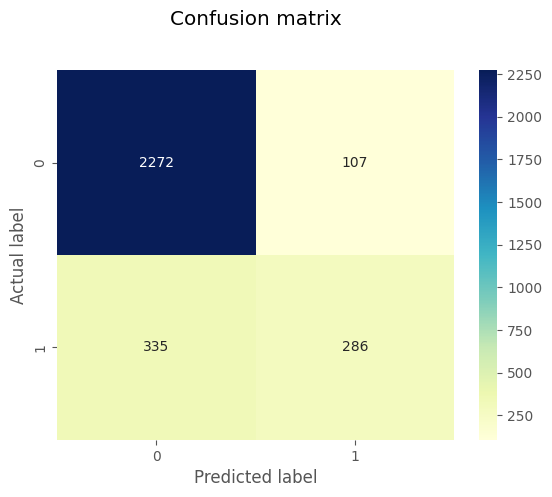

In [40]:
p = sns.heatmap(pd.DataFrame(cm), annot=True, cmap='YlGnBu', fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show();

In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2379
           1       0.73      0.46      0.56       621

    accuracy                           0.85      3000
   macro avg       0.80      0.71      0.74      3000
weighted avg       0.84      0.85      0.84      3000



94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


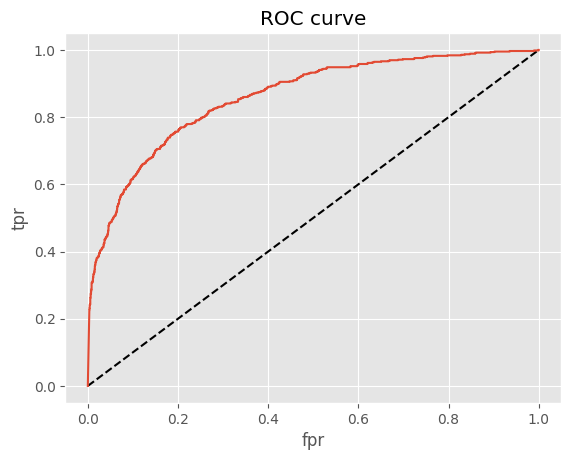

In [43]:
from sklearn.metrics import roc_curve
y_pred_proba = classifier.predict(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
plt.plot([0,1],[0,1], 'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curve')
plt.show()

In [44]:
#Area under ROC curve 
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred_proba)

0.8599724237642983

### Tuning the Model

In [ ]:
# Tuning the ANN
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from keras.models import Sequential
from keras.layers import Dense
def build_classifier(optimizer):
    classifier = Sequential()
    classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu', input_dim = 12))
    classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
    classifier.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
    return classifier
classifier = KerasClassifier(build_fn = build_classifier("adam"))
parameters = {'batch_size': [25, 32],
              'epochs': [100, 200],
              'optimizer': ['adam', 'rmsprop']}
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 10)
grid_search = grid_search.fit(X_train, y_train,verbose = 0)
best_parameters = grid_search.best_params_
best_accuracy = grid_search.best_score_

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/s

In [ ]:
print('Best parametres after tuning : {}'.format(best_parameters))
print('Best Accuracy after tuning : {}'.format(best_accuracy))

### Conclusion

In this project, an Artificial Neural Network (ANN) model was successfully implemented for customer churn prediction using the Churn Modelling dataset. The dataset was preprocessed by handling categorical variables, feature scaling, and splitting into training and testing sets before training the model. 

This project demonstrates how Deep Learning can be applied in real-world business problems to improve customer retention and decision-making. The developed model can help organizations identify potential churn customers in advance and take proactive actions to reduce customer loss.